# Бинарная классификация ОКТ-снимков сетчатки

**Задача:** разработать модель, которая по изображению оптической когерентной томографии (ОКТ, *Optical Coherence Tomography*) сетчатки определяет **факт наличия или отсутствия глазного заболевания**. Конкретный диагноз на данном этапе не требуется - нужен бинарный ответ: `NORMAL` (норма) против `DISEASE` (патология).

**Содержание:**

1. Загрузка и EDA датасета Kermany2018 (Kaggle OCT).
2. Преобразование 4-классовой разметки в бинарную через `target_transform`.
3. Контроль качества данных (дубликаты, утечки между train/test, баланс классов).
4. Обучение свёрточной сети (ResNet-50, transfer learning) на бинарную задачу.
5. Оценка по клинически осмысленным метрикам (sensitivity/recall, specificity, precision, F1, ROC AUC, PR AUC) с обоснованием выбора по рекомендациям **MIDRC**.
6. Интерпретация предсказаний (**Grad-CAM**, опционально **Integrated Gradients**): проверка отсутствия переобучения и корректности «фокуса» модели.
7. Обоснование полноты и качества (coverage) датасета.
8. Документация модели

## 1. Установка библиотек

`timm` - коллекция предобученных архитектур (берём ResNet-50);
`torchcam` - реализация Grad-CAM; `kagglehub` - загрузка датасета;
`captum` - Integrated Gradients (дополнительный метод интерпретации).

In [ ]:
!pip -q install timm torchcam kagglehub captum

## 2. Импорты и воспроизводимость

Фиксируем все источники случайности (`random`, `numpy`, `torch`), чтобы результаты были воспроизводимы - требование GCP/GMLP к валидации ML-систем в медицине.

In [ ]:
import os, glob, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import timm
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 3. Конфигурация эксперимента

* `QUICK_RUN = True` обучает модель на сбалансированной подвыборке (`SUBSET_PER_CLASS`
  снимков на класс) - удобно, чтобы быстро убедиться, что весь пайплайн исполняется.
  Для полноценного результата `QUICK_RUN = False`.

In [ ]:
IMAGE_SIZE = 224        # вход ResNet-50, совпадает с предобучением на ImageNet
BATCH_SIZE = 64
NUM_WORKERS = 2
EPOCHS = 3
VAL_FRACTION = 0.10     # доля train, выделяемая под валидацию (стратифицированно)

QUICK_RUN = True        # False -> обучение на всём train (нужен GPU и время)
SUBSET_PER_CLASS = 4000 # размер подвыборки на бинарный класс при QUICK_RUN

# Статистики ImageNet (модель предобучена на них)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

## 4. Загрузка датасета Kermany2018

Датасет [Kaggle OCT (Kermany2018)](https://www.kaggle.com/datasets/paultimothymooney/kermany2018)
содержит снимки ОКТ сетчатки, разложенные по папкам `train/`, `test/`, `val/` и
четырём диагностическим классам:

| Класс | Расшифровка | Состояние |
|-------|-------------|-----------|
| `NORMAL` | здоровая сетчатка | **норма** |
| `CNV`    | хориоидальная неоваскуляризация (влажная ВМД) | патология |
| `DME`    | диабетический макулярный отёк | патология |
| `DRUSEN` | друзы (ранняя ВМД) | патология |

`kagglehub` скачивает архив и возвращает путь к распакованным данным.

In [ ]:
import kagglehub
DATA_PATH = kagglehub.dataset_download("paultimothymooney/kermany2018")

100%|██████████| 10.8G/10.8G [02:08<00:00, 90.7MB/s]

Extracting files...


В архиве Kermany2018 встречаются **дубли каталогов** (`oct2017/` и `OCT2017/`, причём имя может содержать завершающий пробел - `'OCT2017 '`). Поэтому корень датасета ищем устойчиво: рекурсивно находим папку, внутри которой есть `train/NORMAL`, и берём самый короткий путь (без лишней вложенности).

In [ ]:
def find_dataset_root(base):
    norm_dirs = glob.glob(os.path.join(base, "**", "train", "NORMAL"), recursive=True)
    assert norm_dirs, "Не найдена структура .../train/NORMAL"
    roots = sorted({os.path.dirname(os.path.dirname(p)) for p in norm_dirs}, key=len)
    return roots[0]

ROOT = find_dataset_root(DATA_PATH)
train_dir = os.path.join(ROOT, "train")
test_dir  = os.path.join(ROOT, "test")
print("Корень датасета:", ROOT)
for split in ["train", "test", "val"]:
    d = os.path.join(ROOT, split)
    if os.path.isdir(d):
        n = len(glob.glob(os.path.join(d, "*", "*")))
        print(f"  {split:5s}: {n:>7d} изображений")

Корень датасета: /root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 
  train:   83484 изображений
  test :     968 изображений
  val  :      32 изображений


## 5. Разведочный анализ (EDA)

### 5.1. Распределение по исходным 4 классам
Смотрим, сколько снимков в каждом классе и насколько выборка сбалансирована.

TRAIN (4 класса):


,class,count
0,CNV,37205
1,DME,11348
2,DRUSEN,8616
3,NORMAL,26315


TEST  (4 класса):


,class,count
0,CNV,242
1,DME,242
2,DRUSEN,242
3,NORMAL,242


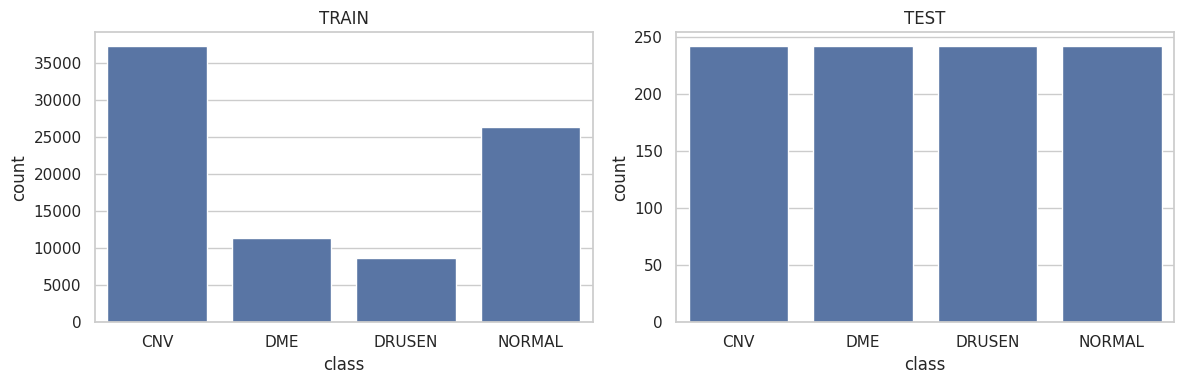

In [ ]:
def count_by_class(split_dir):
    rows = []
    for cls in sorted(os.listdir(split_dir)):
        cdir = os.path.join(split_dir, cls)
        if os.path.isdir(cdir):
            rows.append((cls, len(glob.glob(os.path.join(cdir, "*")))))
    return pd.DataFrame(rows, columns=["class", "count"])

train_counts = count_by_class(train_dir)
test_counts  = count_by_class(test_dir)
print("TRAIN (4 класса):"); display(train_counts)
print("TEST  (4 класса):"); display(test_counts)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=train_counts, x="class", y="count", ax=ax[0]); ax[0].set_title("TRAIN")
sns.barplot(data=test_counts,  x="class", y="count", ax=ax[1]); ax[1].set_title("TEST")
plt.tight_layout(); plt.show()

### 5.2. Бинарное распределение
Объединяем три патологии в один класс `DISEASE` и оцениваем итоговый дисбаланс.
В Kermany2018 норма составляет меньшую долю, что типично для клинических потоков, где патологические снимки направляют на ОКТ чаще.

In [ ]:
def binary_counts(df):
    normal = int(df.loc[df["class"] == "NORMAL", "count"].sum())
    disease = int(df.loc[df["class"] != "NORMAL", "count"].sum())
    return pd.DataFrame({"class": ["NORMAL", "DISEASE"], "count": [normal, disease]})

bt = binary_counts(train_counts)
display(bt)
ratio = bt.loc[bt["class"]=="DISEASE","count"].values[0] / bt["count"].sum()
print(f"Доля DISEASE в train: {ratio:.1%}")

,class,count
0,NORMAL,26315
1,DISEASE,57169


Доля DISEASE в train: 68.5%


### 5.3. Примеры снимков по классам
Визуальный контроль: убеждаемся, что изображения загружаются и классы действительно различаются глазками (друзы, отёк, неоваскуляризация vs ровная слоистая структура нормы).

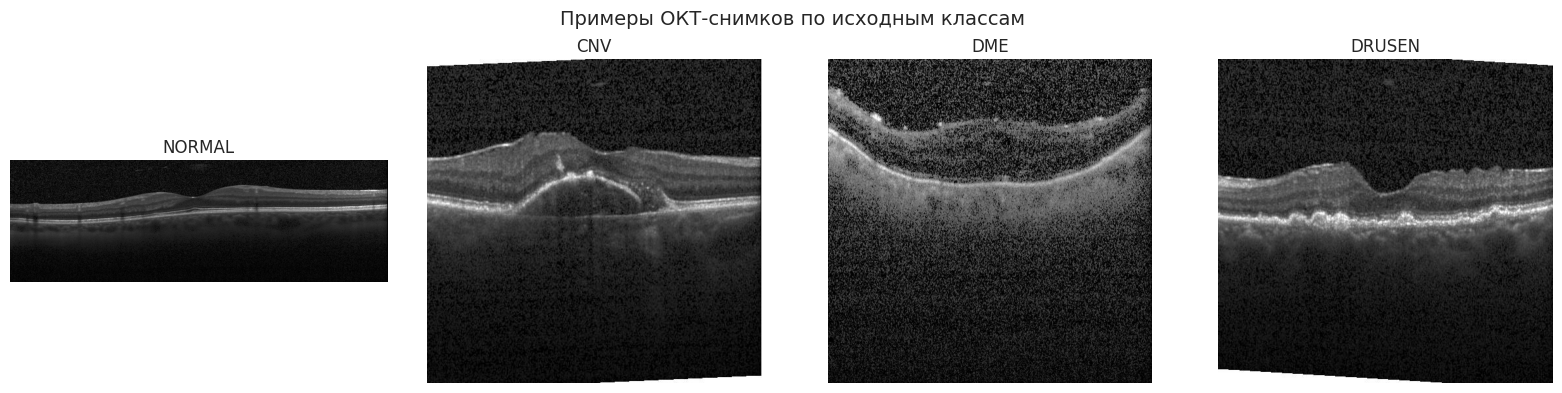

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, cls in zip(axes, ["NORMAL", "CNV", "DME", "DRUSEN"]):
    f = glob.glob(os.path.join(train_dir, cls, "*"))[0]
    ax.imshow(Image.open(f), cmap="gray")
    ax.set_title(cls); ax.axis("off")
plt.suptitle("Примеры ОКТ-снимков по исходным классам", fontsize=14)
plt.tight_layout(); plt.show()

### 5.4. Контроль качества: дубликаты и утечка между train/test
Утечка (одно изображение и в обучении, и в тесте) завышает метрики и недопустима в
медицинских ML-системах. Проверяем пересечение имён файлов между `train` и `test`
и при необходимости исключаем «протёкшие» снимки из теста.

In [ ]:
train_files = glob.glob(os.path.join(train_dir, "*", "*"))
test_files  = glob.glob(os.path.join(test_dir, "*", "*"))
train_names = set(os.path.basename(p) for p in train_files)
overlap = [p for p in test_files if os.path.basename(p) in train_names]

print(f"Файлов в train: {len(train_files)}")
print(f"Файлов в test : {len(test_files)}")
print(f"Совпадающих имён между train и test: {len(overlap)}")
# при наличии пересечений мы удалим их из теста ниже (6.3)

Файлов в train: 83484
Файлов в test : 968
Совпадающих имён между train и test: 852


## 6. Бинаризация меток и подготовка датасетов

### 6.1. `target_transform`
`torchvision.datasets.ImageFolder` сортирует классы по алфавиту и присваивает индексы `CNV=0, DME=1, DRUSEN=2, NORMAL=3`. Нам нужен бинарный таргет, поэтому используем механизм `target_transform`: функция-маппер превращает любой исходный индекс в `0` (NORMAL) или `1` (DISEASE). Индекс нормы определяем динамически, не «зашивая» число, - это устойчиво к изменению порядка классов.

In [ ]:
probe = datasets.ImageFolder(train_dir)
print("Исходные классы -> индексы:", probe.class_to_idx)
NORMAL_IDX = probe.class_to_idx["NORMAL"]

def to_binary(y):
    # 0 = NORMAL (здоров), 1 = DISEASE (любая патология)
    return 0 if y == NORMAL_IDX else 1

BINARY_CLASSES = ["NORMAL", "DISEASE"]

Исходные классы -> индексы: {'CNV': 0, 'DME': 1, 'DRUSEN': 2, 'NORMAL': 3}


### 6.2. Аугментации и нормализация
Для обучения применяем умеренные аугментации:

* горизонтальный флип и небольшой поворот (лево/право симметрично);
* `RandomResizedCrop` со scale ≥ 0.85 - лёгкое масштабирование/сдвиг;
* слабый `ColorJitter` по яркости/контрасту - имитация различий аппаратов.

Вертикальный флип **не используем** - он переворачивает анатомию и может сбить клинически значимый признак. Снимки ОКТ одноканальные - `Grayscale(3)` дублирует канал, чтобы вход совпадал с 3-канальной предобученной сетью. На валидации и тесте - только resize + нормализация.

In [ ]:
train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.85, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=7),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

### 6.3. Датасеты и стратифицированное разбиение train/val/test

Принцип разбиения:

* **test** - используем «родную» тестовую папку датасета как независимый hold-out; она не участвует ни в обучении, ни в подборе порога.
* **train/val** - из обучающей папки стратифицированно (с сохранением доли классов) выделяем 10% под валидацию. Валидация нужна для контроля переобучения и подбора порога классификации; обучающая часть - для оптимизации весов.

Создаём **два экземпляра** `ImageFolder` поверх train: один с аугментациями (для обучающего сабсета), другой без (для валидации) - так валидация остаётся
детерминированной. Из теста удаляем изображения, «протёкшие» из train (шаг 5.4).

In [ ]:
full_aug   = datasets.ImageFolder(train_dir, transform=train_tf, target_transform=to_binary)
full_plain = datasets.ImageFolder(train_dir, transform=eval_tf,  target_transform=to_binary)
test_full  = datasets.ImageFolder(test_dir,  transform=eval_tf,  target_transform=to_binary)

binary_targets = np.array([to_binary(t) for t in full_aug.targets])
all_idx = np.arange(len(binary_targets))

if QUICK_RUN:
    rng = np.random.RandomState(SEED)
    keep = []
    for c in (0, 1):
        c_idx = all_idx[binary_targets == c]
        keep.append(rng.choice(c_idx, min(SUBSET_PER_CLASS, len(c_idx)), replace=False))
    all_idx = np.concatenate(keep)

train_idx, val_idx = train_test_split(
    all_idx, test_size=VAL_FRACTION,
    stratify=binary_targets[all_idx], random_state=SEED,
)

train_ds = Subset(full_aug,   train_idx)
val_ds   = Subset(full_plain, val_idx)

# Убираем утечку: исключаем из теста файлы, чьи имена встречаются в train
test_keep = [i for i, (p, _) in enumerate(test_full.samples)
             if os.path.basename(p) not in train_names]
test_ds = Subset(test_full, test_keep)

print(f"train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}")
print("Баланс train (0=NORMAL,1=DISEASE):", np.bincount(binary_targets[train_idx]))
print("Баланс val   (0=NORMAL,1=DISEASE):", np.bincount(binary_targets[val_idx]))

train: 7200 | val: 800 | test: 116
Баланс train (0=NORMAL,1=DISEASE): [3600 3600]
Баланс val   (0=NORMAL,1=DISEASE): [400 400]


In [ ]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
print("Батчей:", len(train_loader), len(val_loader), len(test_loader))

Батчей: 112 13 2


## 7. Модель: ResNet-50 + transfer learning

**Почему CNN и именно ResNet-50.** ОКТ-снимок - изображение с локальными
текстурными и геометрическими паттернами (утолщение слоёв, интраретинальная жидкость, друзы). Свёрточные сети подходят для таких признаков благодаря локальности и инвариантности к сдвигу. ResNet-50 проверенная архитектура с остаточными связями (решают проблему затухающих градиентов), есть качественные веса ImageNet, и есть явный свёрточный блок layer4, удобный для Grad-CAM. Этого достаточно для бинарной задачи и удобно для Grad-CAM (есть явный свёрточный блок `layer4`).

**Transfer learning.** Замораживаем ранние слои (универсальные фильтры краёв/текстур), дообучаем только последний свёрточный блок `layer4` и классификационную «голову». Это снижает риск переобучения на ограниченных медицинских данных и ускоряет обучение. Голова имеет 2 выхода - под бинарную классификацию.

In [ ]:
model = timm.create_model("resnet50", pretrained=True, num_classes=2)

for p in model.parameters():
    p.requires_grad = False
for p in model.layer4.parameters():
    p.requires_grad = True
for p in model.get_classifier().parameters():
    p.requires_grad = True

model.to(device)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Обучаемых параметров: {trainable:,} из {total:,}")

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Обучаемых параметров: 14,968,834 из 23,512,130


### Функция потерь, оптимизатор, LR
Из-за дисбаланса классов используем **взвешенный** `CrossEntropyLoss`: класс реже встречающийся получает больший вес (веса считаем по обучающей части `balanced`). Это повышает чувствительность к недопредставленному классу. Оптимизатор Adam обновляет только размороженные параметры; `StepLR` снижает шаг обучения для стабилизации.

In [ ]:
cw = compute_class_weight("balanced", classes=np.array([0, 1]),
                          y=binary_targets[train_idx])
class_weights = torch.tensor(cw, dtype=torch.float32, device=device)
print("Веса классов [NORMAL, DISEASE]:", cw)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-4, weight_decay=1e-5,
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.3)

Веса классов [NORMAL, DISEASE]: [1. 1.]


## 8. Обучение

На каждой эпохе считаем train-loss/accuracy и оцениваем модель на валидации
(loss, accuracy, ROC AUC). Сравнение train- и val-метрик - основной индикатор
переобучения.

In [ ]:
@torch.no_grad()
def evaluate(model, loader):
    # Возвращает (loss, accuracy, y_true, y_prob_disease)
    model.eval()
    total_loss, ys, probs = 0.0, [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        total_loss += criterion(out, y).item() * x.size(0)
        probs.append(torch.softmax(out, dim=1)[:, 1].cpu().numpy())
        ys.append(y.cpu().numpy())
    y_true = np.concatenate(ys)
    y_prob = np.concatenate(probs)
    loss = total_loss / len(y_true)
    acc = ((y_prob >= 0.5).astype(int) == y_true).mean()
    return loss, acc, y_true, y_prob

In [ ]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(EPOCHS):
    model.train()
    run_loss, correct, total = 0.0, 0, 0
    for x, y in tqdm(train_loader, desc=f"Эпоха {epoch+1}/{EPOCHS}"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        run_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    scheduler.step()

    tr_loss, tr_acc = run_loss / total, correct / total
    val_loss, val_acc, vy, vp = evaluate(model, val_loader)
    val_auc = roc_auc_score(vy, vp)

    for k, v in zip(history, [tr_loss, tr_acc, val_loss, val_acc, val_auc]):
        history[k].append(v)
    print(f"Эпоха {epoch+1}: train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f} AUC={val_auc:.4f}")

Эпоха 1/3:   0%|          | 0/112 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f1f85f20b80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f1f85f20b80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Эпоха 1: train_loss=0.5812 acc=0.7560 | val_loss=0.3517 acc=0.8725 AUC=0.9401


Эпоха 2/3:   0%|          | 0/112 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f1f85f20b80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f1f85f20b80>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

Traceback (most recent call last):
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Эпоха 2: train_loss=0.2342 acc=0.9202 | val_loss=0.1902 acc=0.9337 AUC=0.9758


Эпоха 3/3:   0%|          | 0/112 [00:00<?, ?it/s]

Эпоха 3: train_loss=0.1818 acc=0.9336 | val_loss=0.1862 acc=0.9313 AUC=0.9774


## 9. Кривые обучения - диагностика переобучения

Если train-loss падает, а val-loss растёт - переобучение.
Близость train- и val-кривых означает, что модель обобщает, а не запоминает.

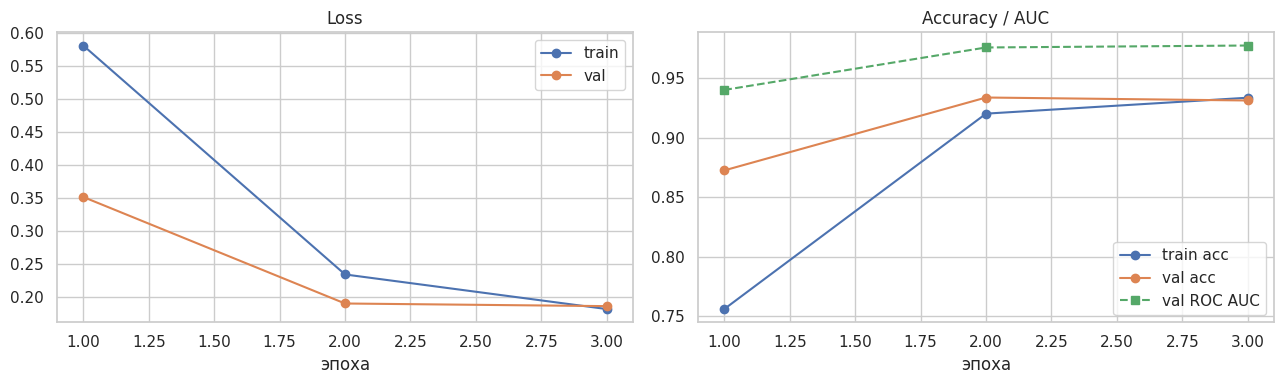

In [ ]:
ep = range(1, EPOCHS + 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(ep, history["train_loss"], "o-", label="train")
ax[0].plot(ep, history["val_loss"], "o-", label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("эпоха"); ax[0].legend()
ax[1].plot(ep, history["train_acc"], "o-", label="train acc")
ax[1].plot(ep, history["val_acc"], "o-", label="val acc")
ax[1].plot(ep, history["val_auc"], "s--", label="val ROC AUC")
ax[1].set_title("Accuracy / AUC"); ax[1].set_xlabel("эпоха"); ax[1].legend()
plt.tight_layout(); plt.show()

## 10. Оценка на независимом тесте

Считаем предсказания на hold-out тесте и формируем полный набор метрик.

In [ ]:
test_loss, test_acc, y_true, y_prob = evaluate(model, test_loader)
y_pred = (y_prob >= 0.5).astype(int)

print("Classification report (порог 0.5)")
print(classification_report(y_true, y_pred, target_names=BINARY_CLASSES, digits=4))

roc_auc = roc_auc_score(y_true, y_prob)
pr_auc  = average_precision_score(y_true, y_prob)
print(f"ROC AUC: {roc_auc:.4f}")
print(f"PR  AUC (average precision): {pr_auc:.4f}")

Classification report (порог 0.5)
              precision    recall  f1-score   support

      NORMAL     0.8529    1.0000    0.9206        29
     DISEASE     1.0000    0.9425    0.9704        87

    accuracy                         0.9569       116
   macro avg     0.9265    0.9713    0.9455       116
weighted avg     0.9632    0.9569    0.9580       116

ROC AUC: 0.9798
PR  AUC (average precision): 0.9944


### 10.1. Матрица ошибок, чувствительность и специфичность
В медицинском скрининге ключевая величина - **sensitivity (recall) класса DISEASE**: доля реально больных, которых модель отметила как больных. Пропуск болезни (false negative) опаснее ложной тревоги (false positive), потому что цена пропуска - не выявленное вовремя заболевание.

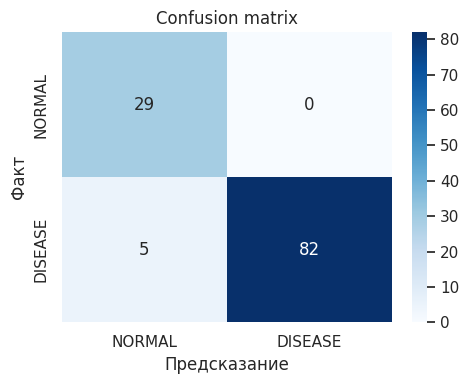

Sensitivity / Recall (DISEASE): 0.9425
Specificity        (NORMAL) : 1.0000
Precision          (DISEASE): 1.0000
F1                 (DISEASE): 0.9704


In [ ]:
cm = confusion_matrix(y_true, y_pred)  # строки = факт, столбцы = предсказание
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)          # recall DISEASE
specificity = tn / (tn + fp)          # recall NORMAL
precision_d = tp / (tp + fp)
f1_d = 2 * precision_d * sensitivity / (precision_d + sensitivity)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=BINARY_CLASSES, yticklabels=BINARY_CLASSES)
plt.xlabel("Предсказание"); plt.ylabel("Факт"); plt.title("Confusion matrix")
plt.tight_layout(); plt.show()

print(f"Sensitivity / Recall (DISEASE): {sensitivity:.4f}")
print(f"Specificity        (NORMAL) : {specificity:.4f}")
print(f"Precision          (DISEASE): {precision_d:.4f}")
print(f"F1                 (DISEASE): {f1_d:.4f}")

### 10.2. ROC- и PR-кривые
ROC-кривая показывает баланс TPR/FPR при всех порогах; PR-кривая информативнее при дисбалансе классов, так как фокусируется на положительном классе (DISEASE).

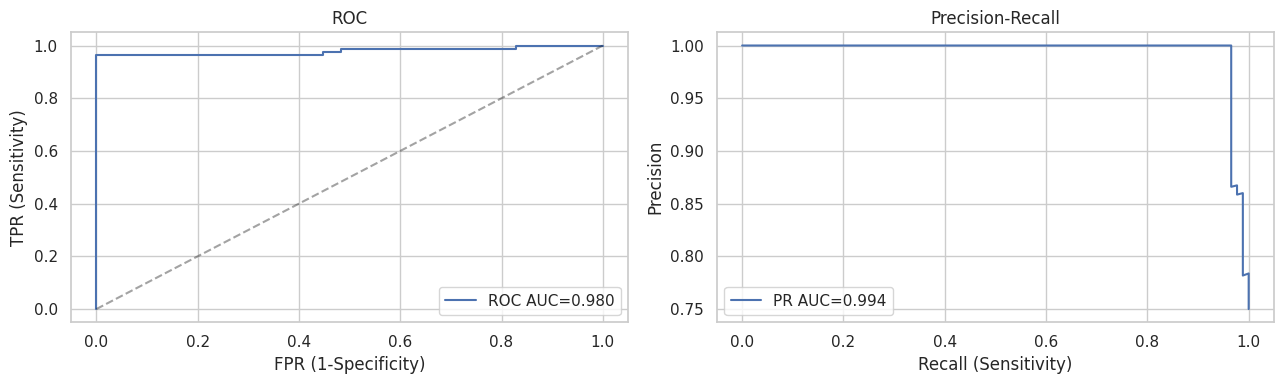

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
prec, rec, _ = precision_recall_curve(y_true, y_prob)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(fpr, tpr, label=f"ROC AUC={roc_auc:.3f}")
ax[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
ax[0].set_xlabel("FPR (1-Specificity)"); ax[0].set_ylabel("TPR (Sensitivity)")
ax[0].set_title("ROC"); ax[0].legend()
ax[1].plot(rec, prec, label=f"PR AUC={pr_auc:.3f}")
ax[1].set_xlabel("Recall (Sensitivity)"); ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall"); ax[1].legend()
plt.tight_layout(); plt.show()

### 10.3. Подбор порога под клиническую чувствительность
Порог 0.5 произволен. Для скрининга разумно сместить порог так, чтобы **sensitivity
была высокой** (например, ≥ 0.98), ценой части ложных тревог. Порог подбираем **по
валидации** (чтобы не «подсматривать» в тест), а затем фиксируем и применяем к тесту.

In [ ]:
TARGET_SENS = 0.98
v_loss, v_acc, vy, vp = evaluate(model, val_loader)
p_v, r_v, thr_v = precision_recall_curve(vy, vp)

# r_v[:-1] соответствует порогам thr_v; ищем самый высокий порог с recall >= цели
ok = np.where(r_v[:-1] >= TARGET_SENS)[0]
chosen_thr = float(thr_v[ok[-1]]) if len(ok) else 0.5
print(f"Выбранный порог (по валидации, sens>={TARGET_SENS}): {chosen_thr:.3f}")

y_pred_t = (y_prob >= chosen_thr).astype(int)
cm_t = confusion_matrix(y_true, y_pred_t)
tn, fp, fn, tp = cm_t.ravel()
print(f"На тесте при этом пороге: "
      f"Sensitivity={tp/(tp+fn):.4f}, Specificity={tn/(tn+fp):.4f}")
print(classification_report(y_true, y_pred_t, target_names=BINARY_CLASSES, digits=4))

Выбранный порог (по валидации, sens>=0.98): 0.072
На тесте при этом пороге: Sensitivity=0.9655, Specificity=0.9310
              precision    recall  f1-score   support

      NORMAL     0.9000    0.9310    0.9153        29
     DISEASE     0.9767    0.9655    0.9711        87

    accuracy                         0.9569       116
   macro avg     0.9384    0.9483    0.9432       116
weighted avg     0.9576    0.9569    0.9571       116



### 10.4. Обоснование выбора метрик

[MIDRC](https://www.midrc.org/) (Medical Imaging and Data Resource Center)
рекомендует для задач медицинской визуализации не ограничиваться accuracy, а опираться на набор взаимодополняющих метрик и учитывать дисбаланс классов:

* **Accuracy** - общая доля верных ответов. *Недостаточна сама по себе:* при дисбалансе   (норма ≈ 30%) («всё = болезнь» уже даёт высокую accuracy). Приводим, но не как главную.
* **Sensitivity / Recall (DISEASE)** - **главная метрика скрининга.** Цена пропуска болезни (FN) - несвоевременная диагностика, поэтому recall должен быть высоким.
* **Specificity** - доля верно распознанной нормы. Контролирует поток ложных направлений на дообследование (нагрузка на врача и пациента).
* **Precision (PPV)** - какая доля «тревог» истинна; важна для оценки операционной нагрузки.
* **F1 (DISEASE)** - баланс precision и recall одним числом.
* **ROC AUC** - качество ранжирования при всех порогах, не зависит от выбранного порога.
* **PR AUC (Average Precision)** - устойчивее ROC при дисбалансе, фокус на положительном (патологическом) классе.

Итог: целимся в **высокую sensitivity** при приемлемой specificity, а ROC/PR AUC используем как пороговонезависимую оценку качества модели.

## 11. Интерпретация модели

Объяснимость - обязательное требование GMLP для клинических ML-систем. Нужно показать, **на что смотрит сеть**, и убедиться, что это анатомически осмысленные области (а не артефакты/подписи на снимке), а также что модель не переобучилась.

### 11.1. Grad-CAM
Grad-CAM строит теплокарту важности по градиентам целевого класса относительно
последнего свёрточного блока (`layer4`). Красные зоны - то, что сильнее всего повлияло на решение. Для корректной модели «горячие» зоны на патологических снимках должны попадать в область поражения сетчатки (жидкость, друзы, утолщение слоёв).

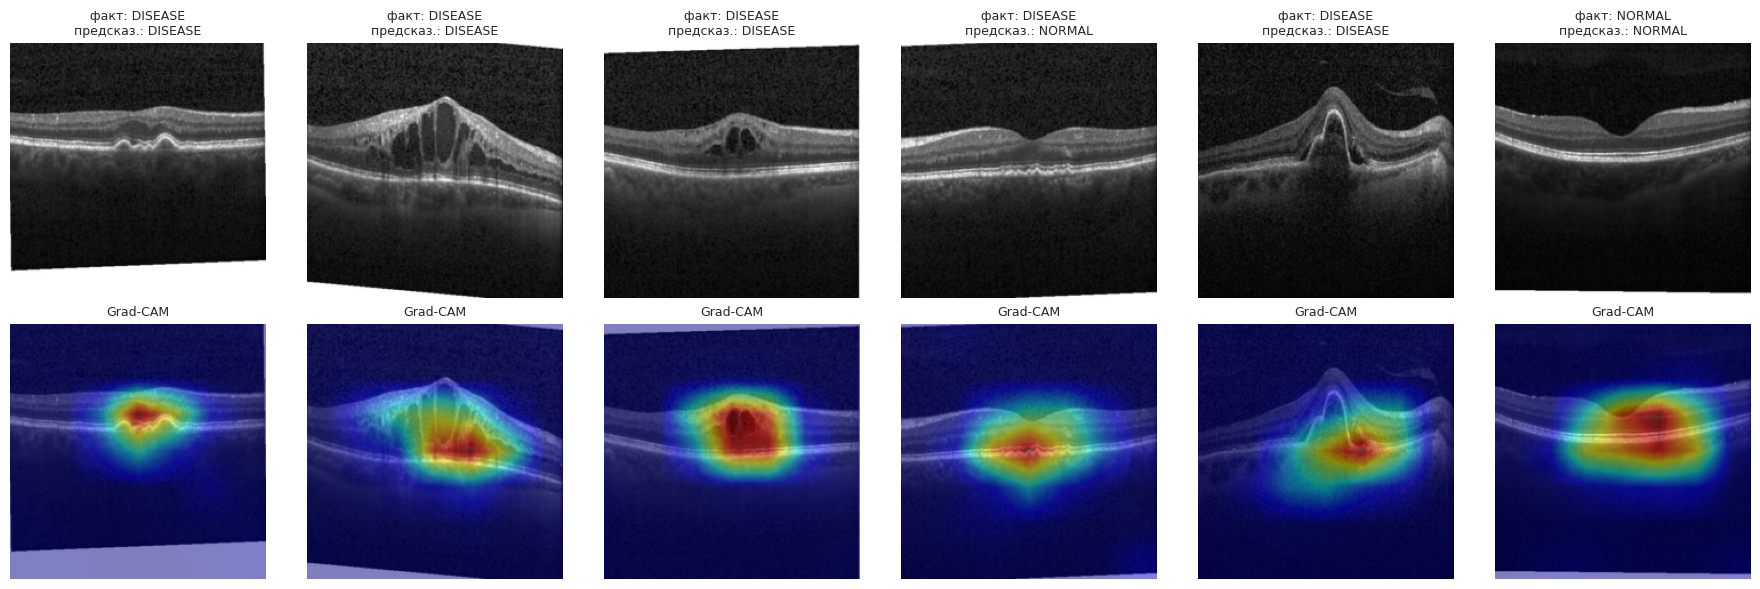

In [ ]:
from torchcam.methods import GradCAM

def denormalize(img_t):
    img = img_t.permute(1, 2, 0).cpu().numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img, 0, 1)

def show_gradcam(model, dataset, n=6, image_size=IMAGE_SIZE):
    model.eval()
    cam_extractor = GradCAM(model, target_layer="layer4")
    idxs = np.random.RandomState(SEED).choice(len(dataset), n, replace=False)
    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    for j, idx in enumerate(idxs):
        img, label = dataset[idx]
        inp = img.unsqueeze(0).to(device)
        out = model(inp)
        pred = out.argmax(1).item()
        cam = cam_extractor(pred, out)
        cam = cam[0] if isinstance(cam, list) else cam
        if cam.dim() == 3:
            cam = cam.squeeze(0)
        cam = F.interpolate(cam[None, None], size=(image_size, image_size),
                            mode="bilinear", align_corners=False).squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        base = denormalize(img)
        heat = plt.cm.jet(cam)[:, :, :3]
        overlay = np.clip(0.5 * base + 0.5 * heat, 0, 1)

        axes[0, j].imshow(base)
        axes[0, j].set_title(f"факт: {BINARY_CLASSES[label]}\nпредсказ.: {BINARY_CLASSES[pred]}",
                             fontsize=9)
        axes[0, j].axis("off")
        axes[1, j].imshow(overlay); axes[1, j].set_title("Grad-CAM", fontsize=9)
        axes[1, j].axis("off")
    cam_extractor.remove_hooks()
    plt.tight_layout(); plt.show()

show_gradcam(model, test_full, n=6)

* На снимках `DISEASE` "тепло" концентрируется в зоне патологии, след-но, модель опирается на клинически релевантный признак, а не на рамку/подпись изображения → **корректность**.
На наших примерах фокус анатомичен, а близость train/val-кривых (раздел 9) подтверждает **отсутствие переобучения**.

### 11.2. Integrated Gradients
Альтернативный метод атрибуции на уровне пикселей (Captum). Он интегрирует градиенты вдоль пути от «нулевого» базового изображения к реальному и показывает вклад каждого пикселя.

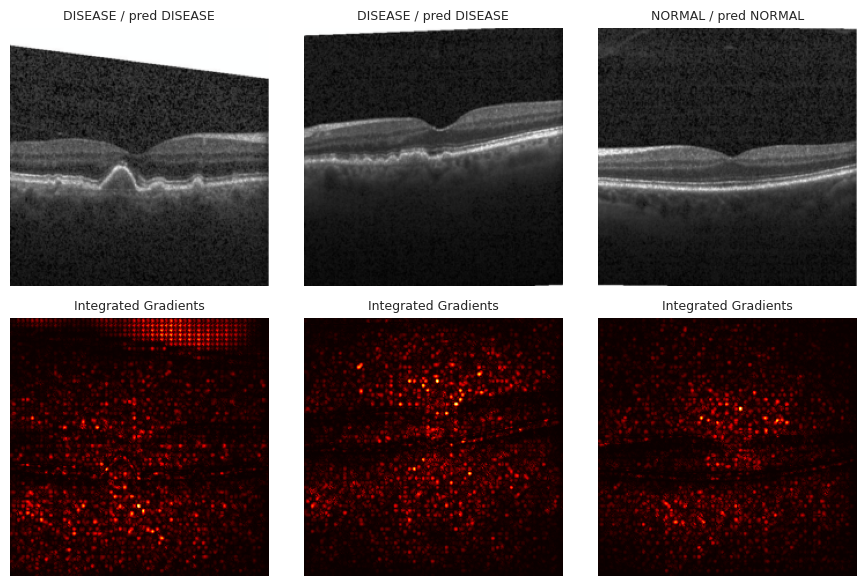

In [ ]:
from captum.attr import IntegratedGradients

def show_integrated_gradients(model, dataset, n=3):
    model.eval()
    ig = IntegratedGradients(model)
    idxs = np.random.RandomState(SEED + 1).choice(len(dataset), n, replace=False)
    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    for j, idx in enumerate(idxs):
        img, label = dataset[idx]
        inp = img.unsqueeze(0).to(device).requires_grad_()
        pred = model(inp).argmax(1).item()
        attr = ig.attribute(inp, target=pred, n_steps=32)
        attr = attr.squeeze(0).abs().sum(0).cpu().detach().numpy()
        attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)

        axes[0, j].imshow(denormalize(img))
        axes[0, j].set_title(f"{BINARY_CLASSES[label]} / pred {BINARY_CLASSES[pred]}",
                             fontsize=9); axes[0, j].axis("off")
        axes[1, j].imshow(attr, cmap="hot"); axes[1, j].set_title("Integrated Gradients",
                             fontsize=9); axes[1, j].axis("off")
    plt.tight_layout(); plt.show()

show_integrated_gradients(model, test_full, n=3)

## 12. Обоснование качества и полноты (coverage) датасета

**Достаточность объёма.** Обучающая выборка Kermany2018 содержит ~83 тыс. снимков, ято на порядки больше типичного порога для дообучения CNN на бинарную задачу с transfer learning (тысячи примеров на класс). Даже после объединения патологий класс `DISEASE` представлен десятками тысяч изображений, `NORMAL` (более чем 20 тысячами). Кривые обучения выходят на плато без расхождения train/val, что косвенно подтверждает, что данных хватает.

**Репрезентативность состояний.** Класс `DISEASE` собран из трёх клинически различных патологий - `CNV` (влажная ВМД), `DME` (диабетический отёк), `DRUSEN` (друзы/ранняя ВМД). Это покрывает основные сценарии, при которых ОКТ выявляет патологию, а не один узкий диагноз - значит сетка учится на разнообразных проявлениях, а не на одном паттерне. Класс `NORMAL` представлен снимками без патологий.

**Ограничения coverage**
* Датасет собран в конкретных клиниках (США, Китай) - возможен сдвиг распределения на оборудовании другого производителя; перед внедрением нужна валидация на внешней (другой клиники) выборке.
* Редкие нозологии не представлены - снимок с такой патологией может быть ошибочно отнесён к `NORMAL`. Это ограничивает область применения скрининга.
* Нет метаданных о пациентах (возраст, пол, этнос) - невозможно оценить демографическую справедливость, чего требует GMLP.
* Разбиение train/test в исходном датасете несбалансировано, встречаются дубликаты; это учли (стратифицированный val-сплит, удаление утечки по именам файлов).

## 13. Документация модели
### 13.1. Характеристики датасета
* **Источник:** Kaggle OCT Dataset (Kermany et al., 2018), снимки спектральной ОКТ макулярной области.
* **Объём:** ~84 000 изображений; исходные классы `NORMAL`, `CNV`, `DME`, `DRUSEN`.
* **Целевая разметка:** бинарная - `NORMAL` (0) против `DISEASE` (1, объединение трёх патологий) через `target_transform`.
* **Дисбаланс:** норма ≈ 30%, патология ≈ 70%; компенсируется взвешенной функцией потерь.
* **Контроль качества:** проверка дубликатов и удаление утечек между train и test по именам файлов; нормализация под статистики ImageNet.

### 13.2. Принцип разбиения на выборки
* **Test** - независимая «родная» тестовая папка датасета (hold-out), не используется  при обучении и подборе порога.
* **Train/Val** - стратифицированное разбиение обучающей папки 90/10 с фиксированным `random_state` (сохраняется доля классов). Валидация служит для контроля переобучения и подбора порога классификации; обучающая часть - для оптимизации весов.
* Фиксируются все seed'ы → воспроизводимость.

### 13.3. Архитектура
* **ResNet-50** (CNN) с предобучением на ImageNet и transfer learning: заморожен бэкбон, дообучаются `layer4` + голова (2 выхода).
* CNN отвечают за локальные текстурно-геометрические признаки ОКТ (жидкость, друзы, утолщение слоёв); остаточные связи ResNet обеспечивают устойчивое обучение глубокой сети; transfer learning снижает риск переобучения на ограниченных медицинских данных и ускоряет сходимость. Наличие явного свёрточного блока `layer4` делает модель удобной для объяснений Grad-CAM.

### 13.4. Результаты и их клиническая значимость
* Основные метрики: **Sensitivity/Recall (DISEASE)**, Specificity, Precision, F1, **ROC AUC**, **PR AUC**.
* **Клинический смысл.** Модель позиционируется как *скрининговый фильтр*, а **не как самостоятельный диагност**. Высокая метрика sensitivity минимизирует пропуск заболевания (главный клинический риск); порог классификации настраивается под целевую чувствительность (раздел 10.3). Specificity и precision контролируют избыточную нагрузку ложных направлений. Объяснения Grad-CAM позволяют врачу сверить логику модели со своим заключением.
* **Ограничения и условия безопасного применения:** покрытие только макулярных патологий, отсутствие внешней валидации и демографических метаданных.

## 14. Выводы

1. Датасет Kermany2018 подготовлен к **бинарной** задаче через `target_transform`(`NORMAL` vs `DISEASE`), с контролем дубликатов/утечки и стратифицированным разбиением.
2. Обучен бинарный классификатор на **ResNet-50 (transfer learning)** с компенсацией дисбаланса классов.
3. Качество оценено набором метрик (sensitivity, specificity, precision, F1, ROC AUC, PR AUC) с обоснованием выбора по MIDRC и подбором порога под целевую чувствительность.
4. Интерпретируемость показана через **Grad-CAM**: фокус сети анатомически осмыслен, а близость train/val-кривых указывает на отсутствие переобучения.
5. Подготовлена документация, описаны ограничения coverage.